# Batched Force Field with Constraints: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 6 of the nvMolKit acceleration series.**

Tutorials 4 and 5 used the one-shot `MMFF/UFFOptimizeMoleculesConfs` helpers. nvMolKit also exposes a lower-level
**batched force field** (`MMFFBatchedForcefield` / `UFFBatchedForcefield`) for when you need more control:

- **Constraints** — distance, position, angle, torsion (per molecule, shared across its conformers).
- **Per-molecule options** — custom `MMFFMolProperties`, `nonBondedThreshold`, `ignoreInterfragInteractions`.
- **Standalone energy / gradient** — `compute_energy()` / `compute_gradients()` without minimizing.

This notebook focuses on **constrained minimization**. We apply the same distance constraint with both backends
and compare the constrained minimum energies.

> **CPU baseline note:** RDKit's constraint API builds one force field at a time
> (`MMFFGetMoleculeForceField` + `MMFFAddDistanceConstraint` + `Minimize`) and has **no native threaded path**
> (unlike `MMFFOptimizeMoleculeConfs(numThreads=...)` in Tutorial 4). To keep the table consistent with the
> earlier tutorials, the `rdkit_16thread` column here is a genuine 16-way **multi-process** baseline (the
> per-molecule loop spread across 16 worker processes). nvMolKit batches the whole constrained set on the GPU.
>
> Import `nvmolkit.types` *before* `nvmolkit.batchedForcefield`, keep only fully-embedded molecules, and run
> from this `examples/tutorials/` directory.


## 1. Setup and GPU check

In [1]:
import copy
import multiprocessing
import time
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles, AddHs, AllChem
from rdkit.Chem.rdDistGeom import ETKDGv3, EmbedMultipleConfs

import nvmolkit
from nvmolkit.types import HardwareOptions                       # import BEFORE batchedForcefield
from nvmolkit.batchedForcefield import MMFFBatchedForcefield

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
N_CPU_THREADS = 16   # consistent with tutorials 1-5 (nvMolKit preprocessing + multi-process CPU baseline)
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters

In [2]:
CONFS_PER_MOL = 10
RANDOM_SEED = 42
MAX_ITERS = 200
FORCE_TOL = 1e-4
NONBONDED_THRESHOLD = 100.0
# Distance constraint applied to each molecule's first bond: hold it in [2.0, 2.5] A (a stretch)
CON_RELATIVE, CON_MIN, CON_MAX, CON_FC = False, 2.0, 2.5, 200.0
SIZES = [10, 25, 50]
MIN_HEAVY, MAX_HEAVY = 15, 30
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"confs/mol={CONFS_PER_MOL}, maxIters={MAX_ITERS}, constraint=[{CON_MIN},{CON_MAX}]A fc={CON_FC}, sizes={SIZES}")

confs/mol=10, maxIters=200, constraint=[2.0,2.5]A fc=200.0, sizes=[10, 25, 50]


## 3. Load molecules and generate the starting conformers (once)

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=10000).iloc[:, 0].tolist()
params = ETKDGv3(); params.randomSeed = RANDOM_SEED

mols_all = []
for s in smis:
    m = MolFromSmiles(s)
    if m is None or not (MIN_HEAVY <= m.GetNumHeavyAtoms() <= MAX_HEAVY):
        continue
    mh = AddHs(m)
    if not AllChem.MMFFHasAllMoleculeParams(mh):
        continue
    EmbedMultipleConfs(mh, numConfs=CONFS_PER_MOL, params=params)
    if mh.GetNumConformers() == CONFS_PER_MOL:
        mols_all.append(mh)
    if len(mols_all) >= max(SIZES):
        break
SIZES = [n for n in SIZES if n <= len(mols_all)]
print(f"Prepared {len(mols_all)} molecules x {CONFS_PER_MOL} conformers; sweep sizes = {SIZES}")

Prepared 50 molecules x 10 conformers; sweep sizes = [10, 25, 50]


## 4. Define the backends (constrained minimization)

Both constrain each molecule's **first bond** to a distance range and minimize. nvMolKit attaches the constraint
via `ff[i].add_distance_constraint(...)` and batches `ff.minimize()`. The RDKit baseline builds a force field
per conformer and calls `MMFFAddDistanceConstraint` + `Minimize` in a loop; we run that loop serially
(1 thread) and spread across 16 worker processes for the multi-core baseline.

In [4]:
def fresh_copies(mols):
    return [copy.deepcopy(m) for m in mols]


def first_bond_atoms(mol):
    b = mol.GetBondWithIdx(0)
    return b.GetBeginAtomIdx(), b.GetEndAtomIdx()


def _rdkit_constrained_one(mol):
    # Constrained MMFF minimize all conformers of one molecule; return their energies.
    props = AllChem.MMFFGetMoleculeProperties(mol)
    i, j = first_bond_atoms(mol)
    energies = []
    for cid in range(mol.GetNumConformers()):
        ff = AllChem.MMFFGetMoleculeForceField(
            mol, props, confId=cid,
            nonBondedThresh=NONBONDED_THRESHOLD, ignoreInterfragInteractions=True,
        )
        ff.MMFFAddDistanceConstraint(i, j, CON_RELATIVE, CON_MIN, CON_MAX, CON_FC)
        ff.Initialize()
        ff.Minimize(maxIts=MAX_ITERS, forceTol=FORCE_TOL)
        energies.append(ff.CalcEnergy())
    return energies


def rdkit_constrained(mols):                       # 1 thread (serial)
    return np.array([e for m in mols for e in _rdkit_constrained_one(m)])


def rdkit_constrained_parallel(mols, workers=N_CPU_THREADS):   # 16-way multi-process
    ctx = multiprocessing.get_context("fork")      # fork: notebook-defined worker is inherited
    with ProcessPoolExecutor(max_workers=workers, mp_context=ctx) as ex:
        results = list(ex.map(_rdkit_constrained_one, mols))
    return np.array([e for sub in results for e in sub])


def nvmolkit_constrained(mols):
    ff = MMFFBatchedForcefield(
        mols, nonBondedThreshold=NONBONDED_THRESHOLD, ignoreInterfragInteractions=True,
        hardwareOptions=HardwareOptions(preprocessingThreads=N_CPU_THREADS),
    )
    for k, m in enumerate(mols):
        i, j = first_bond_atoms(m)
        ff[k].add_distance_constraint(i, j, CON_RELATIVE, CON_MIN, CON_MAX, CON_FC)
    energies, converged = ff.minimize(maxIters=MAX_ITERS, forceTol=FORCE_TOL)
    torch.cuda.synchronize()
    return np.array([e for sub in energies for e in sub])

## 5. Correctness check (constrained energies)

Same constraint, same force field, same iteration cap -> the constrained minimum energies should agree.

In [5]:
sample = mols_all[:max(SIZES)]
rd_e = rdkit_constrained(fresh_copies(sample))
nv_e = nvmolkit_constrained(fresh_copies(sample))

diff = np.abs(rd_e - nv_e)
print(f"conformers compared : {len(rd_e)}")
print(f"mean |Delta E|      : {diff.mean():.4f} kcal/mol")
print(f"median |Delta E|    : {np.median(diff):.4f} kcal/mol")
print(f"max  |Delta E|      : {diff.max():.3f} kcal/mol")
print(f"correlation         : {np.corrcoef(rd_e, nv_e)[0, 1]:.6f}")
print("\n(A few conformers settle in slightly different nearby minima - expected for independent minimizers.)")

conformers compared : 500
mean |Delta E|      : 0.0209 kcal/mol
median |Delta E|    : 0.0000 kcal/mol
max  |Delta E|      : 4.661 kcal/mol
correlation         : 0.999996

(A few conformers settle in slightly different nearby minima - expected for independent minimizers.)


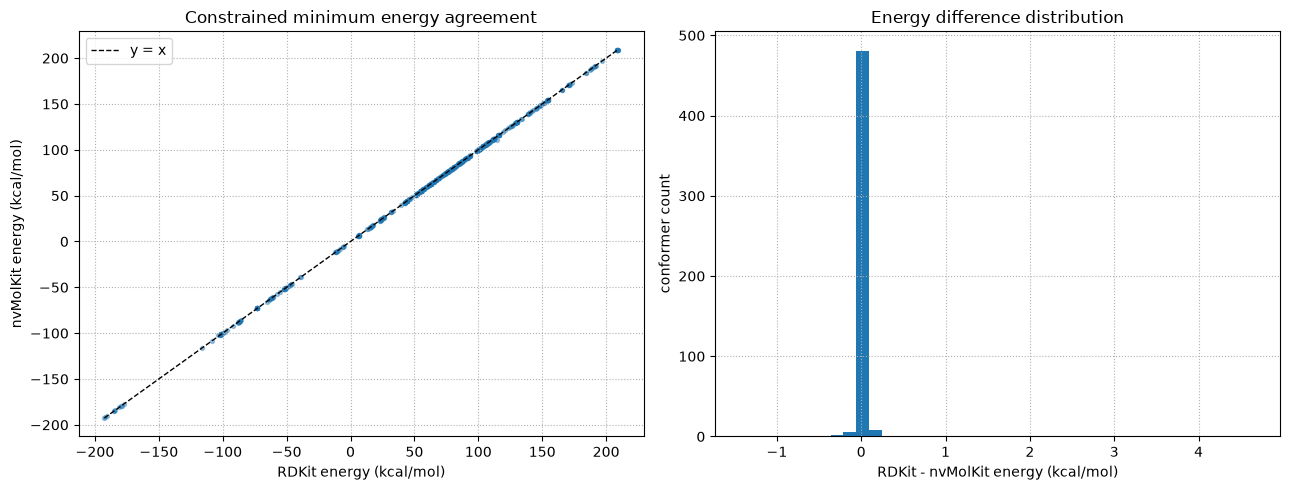

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
lo, hi = min(rd_e.min(), nv_e.min()), max(rd_e.max(), nv_e.max())
ax1.scatter(rd_e, nv_e, s=8, alpha=0.4)
ax1.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax1.set_xlabel("RDKit energy (kcal/mol)")
ax1.set_ylabel("nvMolKit energy (kcal/mol)")
ax1.set_title("Constrained minimum energy agreement")
ax1.legend(); ax1.grid(True, ls=":")

ax2.hist(rd_e - nv_e, bins=40)
ax2.set_xlabel("RDKit - nvMolKit energy (kcal/mol)")
ax2.set_ylabel("conformer count")
ax2.set_title("Energy difference distribution")
ax2.grid(True, ls=":")
plt.tight_layout(); plt.show()

## 6. Warm up the GPU

In [7]:
_ = nvmolkit_constrained(fresh_copies(mols_all[:5]))
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

Columns match the earlier tutorials: RDKit 1-thread (serial), RDKit 16-thread (here 16 worker processes, since
RDKit constraints have no native threaded path), and nvMolKit GPU (batched).

In [8]:
def timed(fn, mols):
    t = time.perf_counter()
    fn(mols)
    torch.cuda.synchronize()
    return time.perf_counter() - t


rows = []
for n in SIZES:
    base = mols_all[:n]
    t_rd1 = timed(rdkit_constrained, fresh_copies(base))
    t_rdN = timed(rdkit_constrained_parallel, fresh_copies(base))
    t_gpu = timed(nvmolkit_constrained, fresh_copies(base))
    total_confs = n * CONFS_PER_MOL
    rows.append({
        "n_mols": n,
        "total_confs": total_confs,
        "rdkit_1thread_s": t_rd1,
        "rdkit_16thread_s": t_rdN,
        "nvmolkit_gpu_s": t_gpu,
        "gpu_confs_per_s": total_confs / t_gpu,
        "speedup_vs_1thread": t_rd1 / t_gpu,
        "speedup_vs_16thread": t_rdN / t_gpu,
    })
    print(f"n={n:4d} | confs={total_confs:5d} | RDKit-1t {t_rd1:7.2f}s | "
          f"RDKit-16t {t_rdN:6.2f}s | nvMolKit {t_gpu:6.3f}s | "
          f"speedup {t_rd1/t_gpu:6.1f}x / {t_rdN/t_gpu:5.1f}x")

df = pd.DataFrame(rows)
df

n=  10 | confs=  100 | RDKit-1t    2.43s | RDKit-16t   0.57s | nvMolKit  0.075s | speedup   32.3x /   7.6x


n=  25 | confs=  250 | RDKit-1t    6.48s | RDKit-16t   1.35s | nvMolKit  0.135s | speedup   48.0x /  10.0x


n=  50 | confs=  500 | RDKit-1t   13.55s | RDKit-16t   2.40s | nvMolKit  0.245s | speedup   55.3x /   9.8x


,n_mols,total_confs,rdkit_1thread_s,rdkit_16thread_s,nvmolkit_gpu_s,gpu_confs_per_s,speedup_vs_1thread,speedup_vs_16thread
0,10,100,2.431894,0.572282,0.075393,1326.378195,32.256110,7.590629
1,25,250,6.479926,1.349853,0.134966,1852.317058,48.011510,10.001421
2,50,500,13.545733,2.399097,0.244857,2042.005666,55.320928,9.797941


## 8. Plot: runtime and speedup vs number of molecules

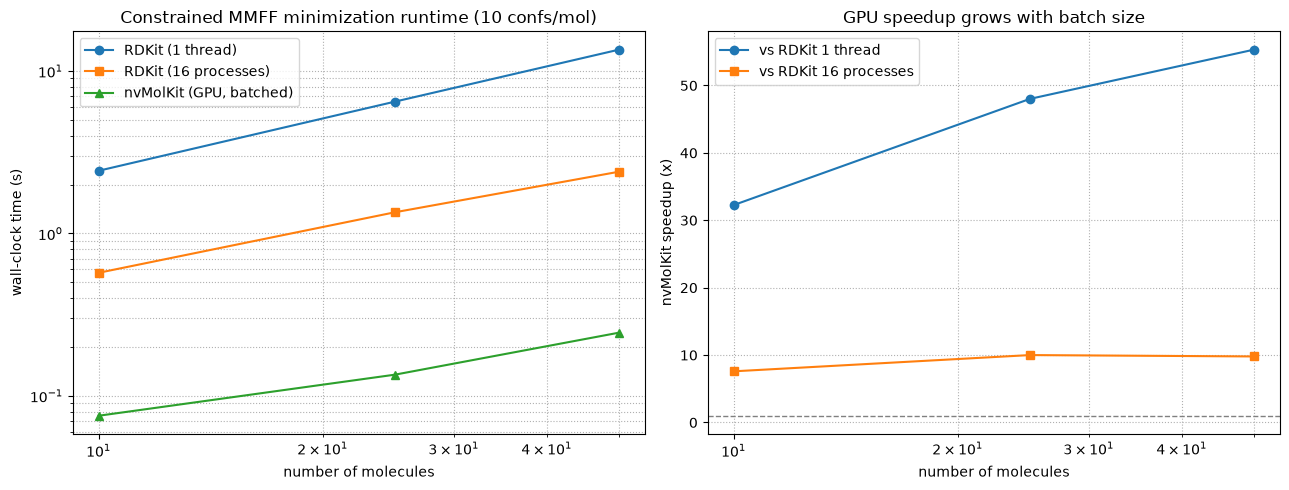

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df["rdkit_16thread_s"], "s-", label="RDKit (16 processes)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU, batched)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title(f"Constrained MMFF minimization runtime ({CONFS_PER_MOL} confs/mol)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="vs RDKit 1 thread")
ax2.plot(df["n_mols"], df["speedup_vs_16thread"], "s-", label="vs RDKit 16 processes")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with batch size")
ax2.set_xscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")
plt.tight_layout(); plt.show()

## 9. Bonus: standalone energy and gradients (no minimization)

`MMFFBatchedForcefield` can also evaluate energies and gradients for the whole batch without minimizing -
useful for scoring or custom optimizers. RDKit has no batched equivalent.

In [10]:
ff = MMFFBatchedForcefield(fresh_copies(mols_all[:5]),
                           hardwareOptions=HardwareOptions(preprocessingThreads=N_CPU_THREADS))
energies = ff.compute_energy()           # list[list[float]] : per molecule, per conformer
grads = ff.compute_gradients()           # list[list[list[float]]] : + per atom (x,y,z)
print(f"energies: {len(energies)} molecules, {len(energies[0])} conformers each")
print(f"mol 0, conf 0 energy : {energies[0][0]:.2f} kcal/mol")
print(f"mol 0, conf 0 grad   : {len(grads[0][0])} atom-gradient components")

energies: 5 molecules, 10 conformers each
mol 0, conf 0 energy : -13.94 kcal/mol
mol 0, conf 0 grad   : 87 atom-gradient components


## 10. Takeaways

- **Same constrained minima.** With an identical distance constraint, nvMolKit's constrained energies match
  RDKit to a fraction of a kcal/mol.
- **Batched where RDKit is serial.** RDKit's constraint API works one force field at a time (no native
  threading); even spread across 16 processes it trails the batched GPU, and nvMolKit's lead grows with the
  batch size.
- **More than minimization.** The same object exposes per-molecule options, four constraint types, and
  standalone `compute_energy()` / `compute_gradients()`. UFF has an identical `UFFBatchedForcefield`.
- **Stay on-device.** `minimize(output=CoordinateOutput.DEVICE)` keeps optimized coordinates on the GPU.

**Next:** Tutorial 7 moves to analysis - pairwise conformer RMSD.